# Notebook 02 v8_1 — Train MaskablePPO Multiphase

In [1]:
from __future__ import annotations

import json
import math
import os
import sys
from dataclasses import asdict, replace
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / "src").exists() and (p / "data").exists():
            return p
    if start.name == "notebooks" and (start.parent / "src").exists():
        return start.parent
    raise FileNotFoundError("Không tìm thấy project root có thư mục src/ và data/. Hãy chạy notebook từ thư mục project.")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = c:\Users\Minh Chau\Music\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT


In [2]:
SEED = 42
TOTAL_TIMESTEPS = 2_500_000
N_ENVS = 4
TRAIN_EPISODE_LENGTH = 320
USE_VM_SNAPSHOT_FOR_MULTIPHASE = True

EXPERIMENT_NAME = f"v8_1_multiphase_seed{SEED}_{TOTAL_TIMESTEPS}"
RUN_DIR = PROJECT_ROOT / "outputs" / "v8_1" / "multiphase_test" / EXPERIMENT_NAME
FIG_DIR = RUN_DIR / "figures"
TRACE_DIR = RUN_DIR / "traces"
for d in [RUN_DIR, FIG_DIR, TRACE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

WORKLOAD_CSV = PROJECT_ROOT / "data" / "workload_real_multiphase.csv"
VM_SNAPSHOT_CSV = PROJECT_ROOT / "data" / "vm_snapshots.csv"

print("RUN_DIR =", RUN_DIR)
print("WORKLOAD_CSV exists:", WORKLOAD_CSV.exists(), WORKLOAD_CSV)
print("VM_SNAPSHOT_CSV exists:", VM_SNAPSHOT_CSV.exists(), VM_SNAPSHOT_CSV)


RUN_DIR = c:\Users\Minh Chau\Music\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\outputs\v8_1\multiphase_test\v8_1_multiphase_seed42_2500000
WORKLOAD_CSV exists: True c:\Users\Minh Chau\Music\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\data\workload_real_multiphase.csv
VM_SNAPSHOT_CSV exists: True c:\Users\Minh Chau\Music\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\data\vm_snapshots.csv


## 1. Load workload và kiểm tra đủ 3 phase

Cell này kiểm tra workload có đủ `low`, `medium`, `high`, mỗi phase có đủ độ dài cho `episode_length = 320`, và tạo danh sách start index để train balanced.

In [3]:
if not WORKLOAD_CSV.exists():
    raise FileNotFoundError(f"Không tìm thấy workload: {WORKLOAD_CSV}")

workload_df = pd.read_csv(WORKLOAD_CSV).reset_index(drop=True)
if "demand" not in workload_df.columns:
    raise ValueError("workload_real_multiphase.csv phải có cột demand")

# Chuẩn hóa / suy luận phase nếu file chưa có phase.
if "phase" not in workload_df.columns:
    workload_df["phase"] = pd.cut(
        workload_df["demand"].astype(float),
        bins=[-np.inf, 0.40, 0.75, np.inf],
        labels=["low", "medium", "high"],
    ).astype(str)
else:
    workload_df["phase"] = workload_df["phase"].astype(str).str.lower().str.strip()
    # Fallback nếu phase lạ/thiếu.
    valid = {"low", "medium", "high"}
    bad_mask = ~workload_df["phase"].isin(valid)
    if bad_mask.any():
        workload_df.loc[bad_mask, "phase"] = pd.cut(
            workload_df.loc[bad_mask, "demand"].astype(float),
            bins=[-np.inf, 0.40, 0.75, np.inf],
            labels=["low", "medium", "high"],
        ).astype(str)

workload = workload_df["demand"].astype(float).to_numpy()

phase_summary = (
    workload_df.groupby("phase", observed=False)["demand"]
    .agg(["count", "min", "mean", "max", "std"])
    .reindex(["low", "medium", "high"])
)
display(phase_summary)

required_phases = {"low", "medium", "high"}
actual_phases = set(workload_df["phase"].dropna().unique())
missing = required_phases - actual_phases
if missing:
    raise ValueError(f"Thiếu phase: {missing}")

if (phase_summary["count"] < TRAIN_EPISODE_LENGTH).any():
    raise ValueError(f"Có phase ngắn hơn TRAIN_EPISODE_LENGTH={TRAIN_EPISODE_LENGTH}")

print("Workload có đủ low/medium/high và mỗi phase đủ dài theo tổng count.")

,count,min,mean,max,std
phase,,,,,
low,1141,0.150000,0.262934,0.399790,0.076733
medium,649,0.400208,0.531602,0.748998,0.099162
high,370,0.750899,0.957857,1.100000,0.107460


Workload có đủ low/medium/high và mỗi phase đủ dài theo tổng count.


In [4]:
def find_phase_segments(df: pd.DataFrame, phase_col: str = "phase") -> pd.DataFrame:
    rows = []
    start = 0
    for i in range(1, len(df)):
        if df.loc[i, phase_col] != df.loc[i - 1, phase_col]:
            sub = df.iloc[start:i]
            rows.append({
                "phase": str(df.loc[start, phase_col]),
                "start": int(start),
                "end": int(i - 1),
                "length": int(i - start),
                "demand_min": float(sub["demand"].min()),
                "demand_mean": float(sub["demand"].mean()),
                "demand_max": float(sub["demand"].max()),
            })
            start = i
    sub = df.iloc[start:]
    rows.append({
        "phase": str(df.loc[start, phase_col]),
        "start": int(start),
        "end": int(len(df) - 1),
        "length": int(len(df) - start),
        "demand_min": float(sub["demand"].min()),
        "demand_mean": float(sub["demand"].mean()),
        "demand_max": float(sub["demand"].max()),
    })
    return pd.DataFrame(rows)

segments = find_phase_segments(workload_df)
valid_segments = segments[segments["length"] >= TRAIN_EPISODE_LENGTH].copy()
print("Phase segments:")
display(segments)
print("Valid segments for pure-phase train episode:")
display(valid_segments)

if set(valid_segments["phase"]) >= {"low", "medium", "high"}:
    print("Có đủ segment liên tục cho low/medium/high với episode_length =", TRAIN_EPISODE_LENGTH)
else:
    raise ValueError("Không đủ segment liên tục cho cả 3 phase.")

Phase segments:


,phase,start,end,length,demand_min,demand_mean,demand_max
0,high,0,369,370,0.750899,0.957857,1.100000
1,medium,370,1018,649,0.400208,0.531602,0.748998
2,low,1019,2159,1141,0.150000,0.262934,0.399790


Valid segments for pure-phase train episode:


,phase,start,end,length,demand_min,demand_mean,demand_max
0,high,0,369,370,0.750899,0.957857,1.100000
1,medium,370,1018,649,0.400208,0.531602,0.748998
2,low,1019,2159,1141,0.150000,0.262934,0.399790


Có đủ segment liên tục cho low/medium/high với episode_length = 320


In [5]:
def build_phase_start_indices(df: pd.DataFrame, episode_length: int, phase_col: str = "phase") -> dict[str, list[int]]:
    segs = find_phase_segments(df, phase_col=phase_col)
    phase_starts: dict[str, list[int]] = {}
    for phase in ["low", "medium", "high"]:
        starts: list[int] = []
        phase_segs = segs[(segs["phase"] == phase) & (segs["length"] >= episode_length)]
        for _, row in phase_segs.iterrows():
            start_min = int(row["start"])
            start_max = int(row["end"]) - episode_length + 1
            starts.extend(range(start_min, start_max + 1))
        phase_starts[phase] = [int(x) for x in starts]
    return phase_starts

PHASE_STARTS = build_phase_start_indices(workload_df, TRAIN_EPISODE_LENGTH)
phase_start_counts = pd.DataFrame([
    {"phase": k, "valid_train_starts": len(v)}
    for k, v in PHASE_STARTS.items()
])
display(phase_start_counts)

if any(len(v) == 0 for v in PHASE_STARTS.values()):
    raise ValueError("Có phase không có valid start index")

# Chọn fixed evaluation windows ở giữa mỗi phase để test rõ low/medium/high.
def choose_mid_window_start(segment_start: int, segment_end: int, episode_length: int) -> int:
    length = segment_end - segment_start + 1
    if length < episode_length:
        raise ValueError("Segment ngắn hơn episode_length")
    return int(segment_start + (length - episode_length) // 2)

EVAL_WINDOWS: dict[str, int] = {}
for phase in ["high", "medium", "low"]:
    phase_rows = valid_segments[valid_segments["phase"] == phase].sort_values("length", ascending=False)
    row = phase_rows.iloc[0]
    EVAL_WINDOWS[phase] = choose_mid_window_start(int(row["start"]), int(row["end"]), TRAIN_EPISODE_LENGTH)

print("Fixed evaluation windows:")
for phase, start in EVAL_WINDOWS.items():
    sub = workload_df.iloc[start:start + TRAIN_EPISODE_LENGTH]
    print(f"{phase:>6}: start={start:4d}, end={start + TRAIN_EPISODE_LENGTH - 1:4d}, mean={sub['demand'].mean():.3f}, counts={sub['phase'].value_counts().to_dict()}")

with open(RUN_DIR / "phase_start_indices_v8_1.json", "w", encoding="utf-8") as f:
    json.dump(PHASE_STARTS, f, ensure_ascii=False, indent=2)

,phase,valid_train_starts
0,low,822
1,medium,330
2,high,51


Fixed evaluation windows:
  high: start=  25, end= 344, mean=0.960, counts={'high': 320}
medium: start= 534, end= 853, mean=0.517, counts={'medium': 320}
   low: start=1429, end=1748, mean=0.260, counts={'low': 320}


## 2. Import môi trường v8_1 và cấu hình reward

Bản v8_1 dùng observation 19 chiều: 17 feature cũ + `demand_trend` + `demand_rolling_mean`. 2 feature mới giúp agent quyết định Sleep/Off an toàn hơn.

In [6]:
from src.energy_env_v8_1 import CloudEnergyEnv, EnvConfig, load_workload_csv

from src.baselines import FixedPolicy, RoundRobinPolicy, ThresholdPolicy, BestFitPolicy, RandomValidPolicy

workload_env = load_workload_csv(str(WORKLOAD_CSV))
assert len(workload_env) == len(workload)

REWARD_OVERRIDES = dict(
    max_hosts=8,
    host_nominal_capacity=1.0 / 7.0,

    reward_w_energy=2.50,
    reward_w_sla=4.35,
    reward_w_latency=0.35,
    reward_w_migration=0.22,
    reward_w_switch=0.09,

    reward_w_overprovision=1.48,
    reward_w_active_excess=1.78,
    reward_w_sleep_excess=0.28,
    reward_w_low_active_excess=0.98,
    reward_w_sticky_config=0.10,

    reward_w_conditional_inaction=0.18,
    reward_w_macro_scale_down_action=0.06,
    reward_w_macro_power_off_action=0.05,
    inaction_demand_threshold=0.56,
    inaction_transition_drop_threshold=0.030,
    inaction_active_margin=1,
    macro_scale_down_demand_threshold=0.62,
    macro_power_off_demand_threshold=0.50,
    macro_active_margin=1,
    macro_max_switches_per_step=1,
    macro_block_if_demand_rising=True,
    macro_demand_rise_threshold=0.035,

    reward_w_dvfs=0.46,
    reward_w_dvfs_mismatch=0.74,
    reward_w_temp=0.34,
    reward_w_lifetime=0.12,
    reward_w_pue=0.055,
    reward_w_cooling=0.12,

    reward_w_power_off_action=0.08,
    reward_w_safe_off_state=0.018,
    reward_w_off_shortage=0.52,
    reward_w_low_transition_action=0.16,
    reward_w_low_scale_down_action=0.10,
    low_load_threshold=0.55,
    low_active_margin=1,

    reward_w_high_load_sleep_off=0.42,
    high_load_threshold=0.75,
    high_load_min_desired_active=7,
    mask_sleep_off_in_high_load=True,

    reward_w_hot_util=0.38,
    hot_util_temp_threshold_c=55.0,
    hot_util_util_threshold=0.86,
    reward_w_high_temp_under_dvfs=0.34,
    reward_w_hot_dvfs_up_action=0.10,
    high_temp_under_dvfs_threshold_c=58.0,
    placement_thermal_weight=0.035,
    placement_hot_util_weight=0.040,
    placement_target_util_for_temp=0.86,

    power_off_bonus_sla_threshold=0.030,
    power_off_bonus_spare_threshold=0.055,
    power_off_bonus_demand_rise_threshold=0.04,

    reward_w_sla_guard=0.48,
    sla_guard_threshold=0.02,
    use_smooth_sla_penalty=True,
    migration_keep_tolerance=0.075,
    migration_norm_scale=120.0,

    dvfs_levels=(0.6, 0.8, 1.0),
    power_dvfs_exponent=3.0,

    obs_include_demand_trend=True,
    obs_demand_trend_offset=3,
    randomize_dvfs_init_by_demand=True,
)

vm_snapshot_path = str(VM_SNAPSHOT_CSV) if (USE_VM_SNAPSHOT_FOR_MULTIPHASE and VM_SNAPSHOT_CSV.exists()) else None
print("vm_snapshot_path =", vm_snapshot_path)

base_train_config = EnvConfig(
    episode_length=TRAIN_EPISODE_LENGTH,
    seed=SEED,
    vm_snapshot_path=vm_snapshot_path,
    balanced_phase_reset=True,
    phase_start_indices=PHASE_STARTS,
    phase_sampling_order=("low", "medium", "high"),
    phase_sampling_probs=(1/3, 1/3, 1/3),
    **REWARD_OVERRIDES,
)

smoke_env = CloudEnergyEnv(workload_env, base_train_config)
rows = []
for i in range(12):
    obs, _ = smoke_env.reset(seed=SEED + i)
    rows.append({
        "i": i,
        "start_idx": smoke_env.start_idx,
        "reset_phase": smoke_env.last_reset_phase,
        "obs_shape": tuple(obs.shape),
        "action_space_n": smoke_env.action_space.n,
        "dvfs_init": smoke_env.dvfs,
        "demand0": smoke_env._get_demand(0),
        "active_init": smoke_env.active_hosts,
        "sleep_init": smoke_env.sleep_hosts,
        "off_init": smoke_env.off_hosts,
        "mask": smoke_env.action_masks().astype(int).tolist(),
    })
smoke_df = pd.DataFrame(rows)
display(smoke_df)
assert smoke_df["reset_phase"].isin(["low", "medium", "high"]).all()
assert smoke_df["obs_shape"].iloc[0] == (19,)
assert smoke_env.action_space.n == 9
assert smoke_env.config.max_hosts == 8
print("Env smoke test passed.")


vm_snapshot_path = c:\Users\Minh Chau\Music\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\data\vm_snapshots.csv


,i,start_idx,reset_phase,obs_shape,action_space_n,dvfs_init,demand0,active_init,sleep_init,off_init,mask
0,0,33,high,"(19,)",9,1.0,1.100000,7,1,0,"[1, 1, 0, 0, 1, 0, 0, 0, 0]"
1,1,502,medium,"(19,)",9,0.8,0.624332,7,1,0,"[1, 1, 1, 1, 1, 1, 0, 0, 0]"
2,2,1691,low,"(19,)",9,0.6,0.240215,4,1,3,"[1, 1, 1, 1, 0, 1, 1, 0, 1]"
3,3,611,medium,"(19,)",9,1.0,0.580092,5,1,2,"[1, 1, 1, 0, 1, 1, 1, 0, 0]"
4,4,11,high,"(19,)",9,1.0,1.099955,7,1,0,"[1, 1, 0, 0, 1, 0, 0, 0, 0]"
5,5,27,high,"(19,)",9,1.0,1.100000,7,1,0,"[1, 1, 0, 0, 1, 0, 0, 0, 0]"
6,6,534,medium,"(19,)",9,1.0,0.605565,6,1,1,"[1, 1, 1, 0, 1, 1, 1, 0, 0]"
7,7,651,medium,"(19,)",9,1.0,0.530476,5,1,2,"[1, 1, 1, 0, 1, 1, 1, 0, 0]"
8,8,36,high,"(19,)",9,1.0,1.100000,7,1,0,"[1, 1, 0, 0, 1, 0, 0, 0, 0]"
9,9,47,high,"(19,)",9,1.0,1.100000,7,1,0,"[1, 1, 0, 0, 1, 0, 0, 0, 0]"


Env smoke test passed.


## 3. Train MaskablePPO v8_1

V8.1 giữ macro-actions nhưng giảm rủi ro migration churn:

- `ent_coef=0.055`, thấp hơn v8 một chút.
- Macro-actions bị block khi demand đang tăng.
- `reward_w_migration` tăng nhẹ.
- `migration_keep_tolerance` tăng để giảm VM churn do grouped snapshots.


In [7]:
try:
    import torch
    from stable_baselines3.common.monitor import Monitor
    from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
    from sb3_contrib import MaskablePPO
except Exception as e:
    raise ImportError(
        "Thiếu thư viện train. Hãy cài: pip install stable-baselines3 sb3-contrib tensorboard"
    ) from e

def make_env(rank: int):
    def _init():
        cfg = replace(base_train_config, seed=SEED + rank)
        env = CloudEnergyEnv(workload_env, cfg)
        return Monitor(env)
    return _init

vec_env = DummyVecEnv([make_env(i) for i in range(N_ENVS)])
vec_env = VecMonitor(vec_env)

policy_kwargs = dict(net_arch=dict(pi=[128, 128], vf=[128, 128]))
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = MaskablePPO(
    "MlpPolicy",
    vec_env,
    learning_rate=2.5e-4,
    n_steps=1024,
    batch_size=256,
    n_epochs=10,
    gamma=0.995,
    gae_lambda=0.95,
    clip_range=0.16,
    ent_coef=0.055,
    vf_coef=0.50,
    max_grad_norm=0.50,
    target_kl=0.030,
    policy_kwargs=policy_kwargs,
    tensorboard_log=str(RUN_DIR / "tb"),
    seed=SEED,
    device=device,
    verbose=1,
)

config_dump = {
    "SEED": SEED,
    "TOTAL_TIMESTEPS": TOTAL_TIMESTEPS,
    "N_ENVS": N_ENVS,
    "TRAIN_EPISODE_LENGTH": TRAIN_EPISODE_LENGTH,
    "USE_VM_SNAPSHOT_FOR_MULTIPHASE": USE_VM_SNAPSHOT_FOR_MULTIPHASE,
    "REWARD_OVERRIDES": {k: (list(v) if isinstance(v, tuple) else v) for k, v in REWARD_OVERRIDES.items()},
    "base_train_config": {k: str(v) if isinstance(v, Path) else v for k, v in asdict(base_train_config).items() if k != "phase_start_indices"},
    "phase_start_counts": {k: len(v) for k, v in PHASE_STARTS.items()},
}
with open(RUN_DIR / "config_v8_1.json", "w", encoding="utf-8") as f:
    json.dump(config_dump, f, ensure_ascii=False, indent=2)

print("Bắt đầu train:", TOTAL_TIMESTEPS, "timesteps")
model.learn(total_timesteps=TOTAL_TIMESTEPS, tb_log_name=EXPERIMENT_NAME, progress_bar=False)
model_path = RUN_DIR / "model_v8_1_maskableppo.zip"
model.save(str(model_path))
print("Saved model:", model_path)

c:\anaconda\envs\nt549-6-chaudnm\Lib\site-packages\stable_baselines3\common\vec_env\vec_monitor.py:43: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


Using device: cpu
Using cpu device
Bắt đầu train: 2500000 timesteps
Logging to c:\Users\Minh Chau\Music\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\outputs\v8_1\multiphase_test\v8_1_multiphase_seed42_2500000\tb\v8_1_multiphase_seed42_2500000_1
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 320       |
|    ep_rew_mean     | -1.32e+03 |
| time/              |           |
|    fps             | 208       |
|    iterations      | 1         |
|    time_elapsed    | 19        |
|    total_timesteps | 4096      |
----------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 320          |
|    ep_rew_mean          | -1.35e+03    |
| time/                   |              |
|    fps                  | 194          |
|    iterations           | 2            |
|    time_elapsed         | 42           |
|    t

## 4. Đường cong học tập / learning reward curve

Cell này vẽ **một biểu đồ reward riêng** và **một biểu đồ hội tụ tổng hợp** để dễ nhìn, không dồn quá nhiều hình.

Found event files: 1
scalars shape: (7323, 4)


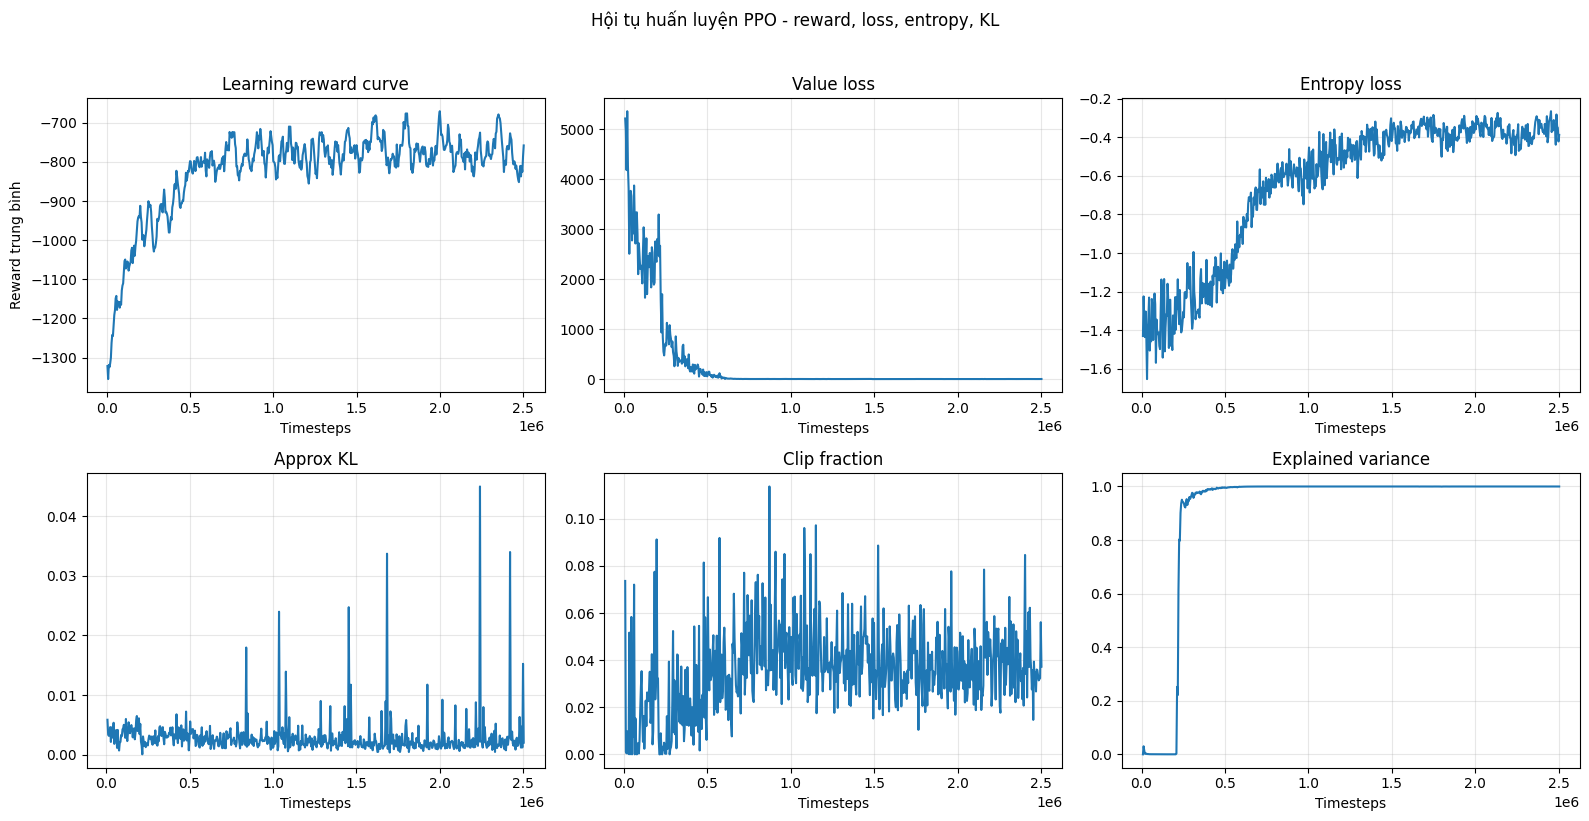

Saved: c:\Users\Minh Chau\Music\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\outputs\v8_1\multiphase_test\v8_1_multiphase_seed42_2500000\figures\01_learning_reward_va_hoi_tu.png


In [8]:
def load_tensorboard_scalars(tb_root: Path) -> pd.DataFrame:
    try:
        from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
    except Exception as e:
        print("Không đọc được TensorBoard vì thiếu tensorboard:", e)
        return pd.DataFrame()

    rows = []
    event_files = list(tb_root.rglob("events.out.tfevents.*"))
    print("Found event files:", len(event_files))
    for event_file in event_files:
        try:
            ea = EventAccumulator(str(event_file))
            ea.Reload()
            for tag in ea.Tags().get("scalars", []):
                for ev in ea.Scalars(tag):
                    rows.append({"file": str(event_file), "tag": tag, "step": ev.step, "value": ev.value})
        except Exception as e:
            print("Skip event file", event_file, e)
    return pd.DataFrame(rows)

scalars_df = load_tensorboard_scalars(RUN_DIR / "tb")
scalars_df.to_csv(RUN_DIR / "tensorboard_scalars_v8_1.csv", index=False)
print("scalars shape:", scalars_df.shape)

def plot_scalar(ax, df, tag, title, ylabel=None):
    sub = df[df["tag"] == tag].sort_values("step")
    if sub.empty:
        ax.text(0.5, 0.5, f"Thiếu dữ liệu\n{tag}", ha="center", va="center")
        ax.set_title(title)
        return
    ax.plot(sub["step"], sub["value"])
    ax.set_title(title)
    ax.set_xlabel("Timesteps")
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
plots = [
    ("rollout/ep_rew_mean", "Learning reward curve", "Reward trung bình"),
    ("train/value_loss", "Value loss", None),
    ("train/entropy_loss", "Entropy loss", None),
    ("train/approx_kl", "Approx KL", None),
    ("train/clip_fraction", "Clip fraction", None),
    ("train/explained_variance", "Explained variance", None),
]
for ax, (tag, title, ylabel) in zip(axes.ravel(), plots):
    plot_scalar(ax, scalars_df, tag, title, ylabel=ylabel)

fig.suptitle("Hội tụ huấn luyện PPO - reward, loss, entropy, KL", y=1.02)
fig.tight_layout()
fig_path = FIG_DIR / "01_learning_reward_va_hoi_tu.png"
fig.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)


### 4.1 - Learning reward riêng

Biểu đồ compact 2x3 ở trên dùng để xem hội tụ tổng quát. Cell này tách riêng `rollout/ep_rew_mean` để dễ đưa vào báo cáo.


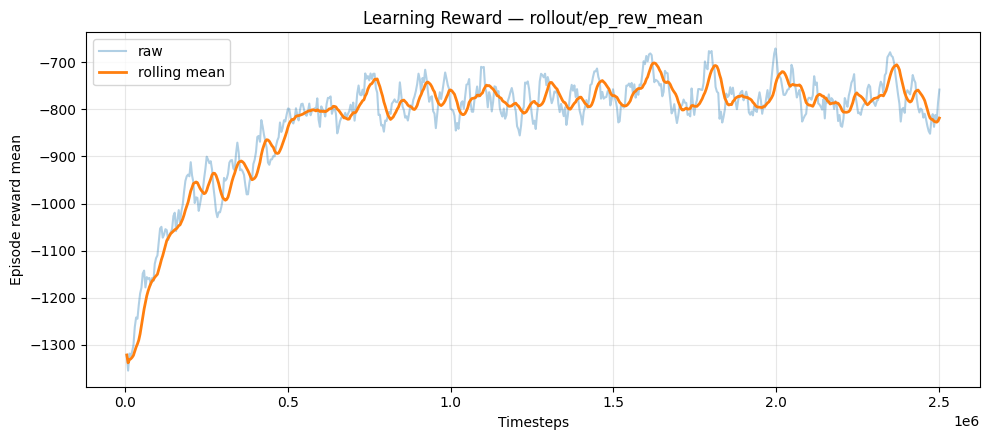

Saved: c:\Users\Minh Chau\Music\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\outputs\v8_1\multiphase_test\v8_1_multiphase_seed42_2500000\figures\01a_learning_reward_mean.png


In [9]:
reward_tag = "rollout/ep_rew_mean"
reward_sub = scalars_df[scalars_df["tag"] == reward_tag].sort_values("step").copy()

if reward_sub.empty:
    print("Không có rollout/ep_rew_mean trong TensorBoard scalars.")
else:
    reward_sub["rolling_mean"] = reward_sub["value"].rolling(10, min_periods=1).mean()

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(reward_sub["step"], reward_sub["value"], alpha=0.35, label="raw")
    ax.plot(reward_sub["step"], reward_sub["rolling_mean"], linewidth=2.0, label="rolling mean")
    ax.set_title("Learning Reward — rollout/ep_rew_mean")
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Episode reward mean")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()

    fig_path = FIG_DIR / "01a_learning_reward_mean.png"
    fig.savefig(fig_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)


## 5. Evaluation: full workload + fixed phase windows

Phần này đánh giá PPO và baseline trên toàn bộ workload để chắc chắn cover đủ 3 phase. Sau đó đánh giá PPO riêng trên 3 cửa sổ fixed low/medium/high.

In [10]:
def predict_action(policy: Any, env: CloudEnergyEnv, obs: np.ndarray, deterministic: bool = True) -> int:
    action_mask = env.action_masks() if hasattr(env, "action_masks") else None
    if isinstance(policy, RandomValidPolicy):
        action, _ = policy.predict(obs, action_mask=action_mask)
        return int(np.asarray(action).item())
    if hasattr(policy, "policy"):
        try:
            action, _ = policy.predict(obs, deterministic=deterministic, action_masks=action_mask)
        except TypeError:
            action, _ = policy.predict(obs, deterministic=deterministic)
        return int(np.asarray(action).item())
    try:
        action, _ = policy.predict(obs)
    except TypeError:
        action, _ = policy.predict(obs, action_mask=action_mask)
    return int(np.asarray(action).item())

def trace_to_dataframe(trace: list[dict[str, Any]], policy_name: str) -> pd.DataFrame:
    rows = []
    for local_step, item in enumerate(trace):
        global_t = int(item.get("global_timestep", local_step))
        phase = str(workload_df.loc[global_t, "phase"]) if 0 <= global_t < len(workload_df) else "unknown"
        row = {
            "policy": policy_name,
            "step": local_step,
            "global_timestep": global_t,
            "phase": phase,
            "demand": float(item.get("demand", 0.0)),
            "power_it": float(item.get("power_it", 0.0)),
            "power_total": float(item.get("power_total", item.get("power", 0.0))),
            "pue": float(item.get("pue", 1.0)),
            "cooling_power": float(item.get("cooling_power", 0.0)),
            "sla_violation": float(item.get("sla_violation", item.get("sla", 0.0))),
            "active_hosts": int(item.get("active_hosts", 0)),
            "sleep_hosts": int(item.get("sleep_hosts", 0)),
            "off_hosts": int(item.get("off_hosts", 0)),
            "dvfs": float(item.get("dvfs", 0.0)),
            "mean_util": float(item.get("mean_util", 0.0)),
            "avg_temp": float(item.get("avg_temp", 0.0)),
            "max_temp": float(item.get("max_temp", 0.0)),
            "migrations": int(item.get("migrations", 0)),
            "migration_cost": float(item.get("migration_cost", 0.0)),
            "switches": int(item.get("switches", 0)),
            "action": int(item.get("action", -1)),
            "action_name": str(item.get("action_name", "UNKNOWN")),
            "action_valid": bool(item.get("action_valid", True)),
            "reward_total": float(item.get("reward_total", 0.0)),
            "uses_vm_snapshots": bool(item.get("uses_vm_snapshots", False)),
        }
        for k, v in (item.get("reward_groups", {}) or {}).items():
            row[f"reward_group_{k}"] = float(v)
        for k, v in (item.get("reward_weighted_components", {}) or {}).items():
            row[f"reward_weighted_{k}"] = float(v)
        rows.append(row)
    return pd.DataFrame(rows)

def summarize_trace(df: pd.DataFrame, policy_name: str) -> dict[str, Any]:
    action_counts = df["action_name"].value_counts().to_dict() if "action_name" in df.columns else {}
    total_steps = max(len(df), 1)
    return {
        "policy": policy_name,
        "steps": int(len(df)),
        "uses_vm_snapshots": bool(df["uses_vm_snapshots"].any()) if "uses_vm_snapshots" in df.columns else False,
        "total_energy": float(df["power_total"].sum()),
        "total_it_energy": float(df["power_it"].sum()),
        "avg_power": float(df["power_total"].mean()),
        "avg_pue": float(df["pue"].mean()),
        "avg_sla": float(df["sla_violation"].mean()),
        "max_sla": float(df["sla_violation"].max()),
        "sla_step_rate": float((df["sla_violation"] > 1e-6).mean()),
        "avg_active_hosts": float(df["active_hosts"].mean()),
        "avg_sleep_hosts": float(df["sleep_hosts"].mean()),
        "avg_off_hosts": float(df["off_hosts"].mean()),
        "avg_dvfs": float(df["dvfs"].mean()),
        "avg_temp": float(df["avg_temp"].mean()),
        "max_temp": float(df["max_temp"].max()),
        "total_migrations": int(df["migrations"].sum()),
        "total_migration_cost": float(df["migration_cost"].sum()),
        "total_switches": int(df["switches"].sum()),
        "keep_rate": float((df["action_name"] == "KEEP").mean()),
        "power_off_count": int((df["action_name"] == "POWER_OFF_ONE").sum()),
        "sleep_count": int((df["action_name"] == "SLEEP_ONE").sum()),
        "wake_count": int((df["action_name"] == "WAKE_ONE").sum()),
        "dvfs_down_count": int((df["action_name"] == "DVFS_DOWN").sum()),
        "dvfs_up_count": int((df["action_name"] == "DVFS_UP").sum()),
        "distinct_actions": int(df["action_name"].nunique()),
        "action_counts_json": json.dumps(action_counts, ensure_ascii=False),
    }

def make_eval_env(episode_length: int, seed: int = SEED) -> CloudEnergyEnv:
    cfg = EnvConfig(
        episode_length=episode_length,
        seed=seed,
        vm_snapshot_path=vm_snapshot_path,
        balanced_phase_reset=False,
        phase_start_indices=PHASE_STARTS,
        **REWARD_OVERRIDES,
    )
    return CloudEnergyEnv(workload_env, cfg)

def run_policy_episode(policy_name: str, policy: Any, episode_length: int, start_idx: int, phase_label: str = "fixed") -> tuple[pd.DataFrame, dict[str, Any]]:
    env = make_eval_env(episode_length=episode_length, seed=SEED)
    obs, _ = env.reset(seed=SEED, options={"start_idx": int(start_idx), "phase": phase_label})
    done = False
    while not done:
        action = predict_action(policy, env, obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        done = bool(terminated or truncated)
    df = trace_to_dataframe(env.trace, policy_name)
    summary = summarize_trace(df, policy_name)
    summary["episode_length"] = episode_length
    summary["start_idx"] = start_idx
    summary["phase_label"] = phase_label
    return df, summary

In [11]:
FULL_EVAL_LENGTH = len(workload_env) - 1
policies = {
    "PPO_v8_1": model,
    "Fixed-Keep": FixedPolicy(action=0),
    "RoundRobin": RoundRobinPolicy(),
    "Threshold": ThresholdPolicy(high=0.85, low=0.25),
    "BestFit": BestFitPolicy(target_util=0.70),
    "RandomValid": RandomValidPolicy(seed=SEED),
}

full_traces = {}
full_summaries = []
for name, policy in policies.items():
    print("Evaluating full workload:", name)
    df_trace, summary = run_policy_episode(name, policy, episode_length=FULL_EVAL_LENGTH, start_idx=0, phase_label="full")
    full_traces[name] = df_trace
    full_summaries.append(summary)
    df_trace.to_csv(TRACE_DIR / f"full_trace_{name}.csv", index=False)

results_df = pd.DataFrame(full_summaries).sort_values("total_energy")
results_df.to_csv(RUN_DIR / "evaluation_results_v8_1.csv", index=False)
display(results_df)

ppo_energy = float(results_df.loc[results_df["policy"] == "PPO_v8_1", "total_energy"].iloc[0])
saving_rows = []
for _, row in results_df.iterrows():
    if row["policy"] == "PPO_v8_1":
        continue
    saving_rows.append({
        "baseline": row["policy"],
        "baseline_energy": float(row["total_energy"]),
        "ppo_energy": ppo_energy,
        "energy_saving_pct": 100.0 * (float(row["total_energy"]) - ppo_energy) / max(float(row["total_energy"]), 1e-9),
    })
energy_saving_df = pd.DataFrame(saving_rows).sort_values("energy_saving_pct", ascending=False)
energy_saving_df.to_csv(RUN_DIR / "energy_saving_vs_baselines_v8_1.csv", index=False)
display(energy_saving_df)

Evaluating full workload: PPO_v8_1
Evaluating full workload: Fixed-Keep
Evaluating full workload: RoundRobin
Evaluating full workload: Threshold
Evaluating full workload: BestFit
Evaluating full workload: RandomValid


,policy,steps,uses_vm_snapshots,total_energy,total_it_energy,avg_power,avg_pue,avg_sla,max_sla,sla_step_rate,avg_active_hosts,avg_sleep_hosts,avg_off_hosts,avg_dvfs,avg_temp,max_temp,total_migrations,total_migration_cost,total_switches,keep_rate,power_off_count,sleep_count,wake_count,dvfs_down_count,dvfs_up_count,distinct_actions,action_counts_json,episode_length,start_idx,phase_label
0,PPO_v8_1,2159,True,2.002077e+06,1.393182e+06,927.316959,1.438327,0.001081,0.077452,0.049097,5.552571,0.214451,2.232978,0.648912,48.814064,66.999992,757,104.442646,170,0.917554,3,85,80,5,3,7,"{""KEEP"": 1981, ""SLEEP_ONE"": 85, ""WAKE_ONE"": 80...",2159,0,full
5,RandomValid,2159,True,2.112917e+06,1.507219e+06,978.655177,1.407747,0.054928,0.793159,0.211672,5.428439,0.818434,1.753126,0.813432,46.311751,66.975571,58032,5844.220957,1002,0.219546,138,289,153,342,341,9,"{""KEEP"": 474, ""DVFS_DOWN"": 342, ""DVFS_UP"": 341...",2159,0,full
4,BestFit,2159,True,2.396498e+06,1.720093e+06,1110.003659,1.397576,0.000000,0.000000,0.000000,5.529412,2.470588,0.000000,0.825753,47.260492,66.999992,562,77.835791,6,0.562297,0,5,1,939,0,4,"{""KEEP"": 1214, ""DVFS_DOWN"": 939, ""SLEEP_ONE"": ...",2159,0,full
2,RoundRobin,2159,True,2.622074e+06,1.923424e+06,1214.485506,1.377341,0.012834,0.310198,0.075961,6.666512,1.333488,0.000000,0.859101,48.021899,66.999992,34486,1071.407116,303,0.647059,0,154,149,459,0,4,"{""KEEP"": 1397, ""DVFS_DOWN"": 459, ""SLEEP_ONE"": ...",2159,0,full
3,Threshold,2159,True,2.670609e+06,1.964756e+06,1236.965920,1.373392,0.010233,0.257271,0.073182,6.668828,1.331172,0.000000,0.911348,47.911732,66.999992,27710,769.372524,313,0.764706,0,159,154,195,0,4,"{""KEEP"": 1651, ""DVFS_DOWN"": 195, ""SLEEP_ONE"": ...",2159,0,full
1,Fixed-Keep,2159,True,2.785342e+06,2.059208e+06,1290.107466,1.338653,0.005175,0.090909,0.060213,7.000000,1.000000,0.000000,1.000000,47.863355,66.999992,12925,473.707735,0,1.000000,0,0,0,0,0,1,"{""KEEP"": 2159}",2159,0,full


,baseline,baseline_energy,ppo_energy,energy_saving_pct
4,Fixed-Keep,2.785342e+06,2.002077e+06,28.120952
3,Threshold,2.670609e+06,2.002077e+06,25.032942
2,RoundRobin,2.622074e+06,2.002077e+06,23.645284
1,BestFit,2.396498e+06,2.002077e+06,16.458207
0,RandomValid,2.112917e+06,2.002077e+06,5.245792


In [12]:
phase_traces = []
phase_summaries = []
for phase, start_idx in EVAL_WINDOWS.items():
    print("Evaluating PPO fixed phase:", phase, start_idx)
    df_phase, summary = run_policy_episode("PPO_v8_1", model, episode_length=TRAIN_EPISODE_LENGTH, start_idx=start_idx, phase_label=phase)
    df_phase["eval_window"] = phase
    phase_traces.append(df_phase)
    phase_summaries.append(summary)
    df_phase.to_csv(TRACE_DIR / f"phase_trace_PPO_v8_1_{phase}.csv", index=False)

phase_eval_df = pd.DataFrame(phase_summaries)
phase_eval_df.to_csv(RUN_DIR / "fixed_phase_eval_results_v8_1.csv", index=False)
display(phase_eval_df)

ppo_full_trace = full_traces["PPO_v8_1"].copy()
ppo_phase_summary = (
    ppo_full_trace.groupby("phase", observed=False)
    .agg(
        steps=("step", "count"),
        demand_mean=("demand", "mean"),
        power_mean=("power_total", "mean"),
        pue_mean=("pue", "mean"),
        sla_mean=("sla_violation", "mean"),
        sla_max=("sla_violation", "max"),
        active_mean=("active_hosts", "mean"),
        sleep_mean=("sleep_hosts", "mean"),
        off_mean=("off_hosts", "mean"),
        dvfs_mean=("dvfs", "mean"),
        temp_mean=("avg_temp", "mean"),
        migrations_sum=("migrations", "sum"),
    )
    .reindex(["low", "medium", "high"])
)
ppo_phase_summary.to_csv(RUN_DIR / "ppo_phase_summary_v8_1.csv")
display(ppo_phase_summary)

if set(ppo_phase_summary.dropna().index) >= {"low", "medium", "high"}:
    print("Full evaluation covers all low/medium/high phases.")
else:
    print("WARNING: Full evaluation does not cover all phases.")

Evaluating PPO fixed phase: high 25
Evaluating PPO fixed phase: medium 534
Evaluating PPO fixed phase: low 1429


,policy,steps,uses_vm_snapshots,total_energy,total_it_energy,avg_power,avg_pue,avg_sla,max_sla,sla_step_rate,avg_active_hosts,avg_sleep_hosts,avg_off_hosts,avg_dvfs,avg_temp,max_temp,total_migrations,total_migration_cost,total_switches,keep_rate,power_off_count,sleep_count,wake_count,dvfs_down_count,dvfs_up_count,distinct_actions,action_counts_json,episode_length,start_idx,phase_label
0,PPO_v8_1,320,True,587372.542698,405655.403198,1835.539196,1.448455,0.001467,0.019808,0.140625,8.000000,0.000000,0.000000,0.879375,63.627780,66.999992,170,32.258839,1,0.987500,0,0,1,2,1,4,"{""KEEP"": 316, ""DVFS_DOWN"": 2, ""WAKE_ONE"": 1, ""...",320,25,high
1,PPO_v8_1,320,True,333832.152920,235685.290747,1043.225478,1.416789,0.000029,0.009189,0.003125,7.253125,0.050000,0.696875,0.600000,54.652347,62.999985,283,32.448864,31,0.900000,2,15,14,1,0,5,"{""KEEP"": 288, ""SLEEP_ONE"": 15, ""WAKE_ONE"": 14,...",320,534,medium
2,PPO_v8_1,320,True,182677.904261,127993.246790,570.868451,1.427057,0.000000,0.000000,0.000000,4.000000,0.009375,3.990625,0.600000,40.322344,62.857048,0,0.000000,3,0.990625,1,1,0,0,0,4,"{""KEEP"": 317, ""SLEEP_ONE"": 1, ""POWER_OFF_EXCES...",320,1429,low


,steps,demand_mean,power_mean,pue_mean,sla_mean,sla_max,active_mean,sleep_mean,off_mean,dvfs_mean,temp_mean,migrations_sum
phase,,,,,,,,,,,,
low,1140,0.263033,565.053300,1.442759,0.000000,0.000000,3.865789,0.366667,3.767544,0.600000,40.465906,243
medium,649,0.531602,1042.033000,1.425189,0.002874,0.077452,7.120185,0.069337,0.810478,0.601849,55.055703,326
high,370,0.957857,1842.262531,1.447717,0.001269,0.019808,8.000000,0.000000,0.000000,0.882162,63.587245,188


Full evaluation covers all low/medium/high phases.


## 6. Compact dashboards

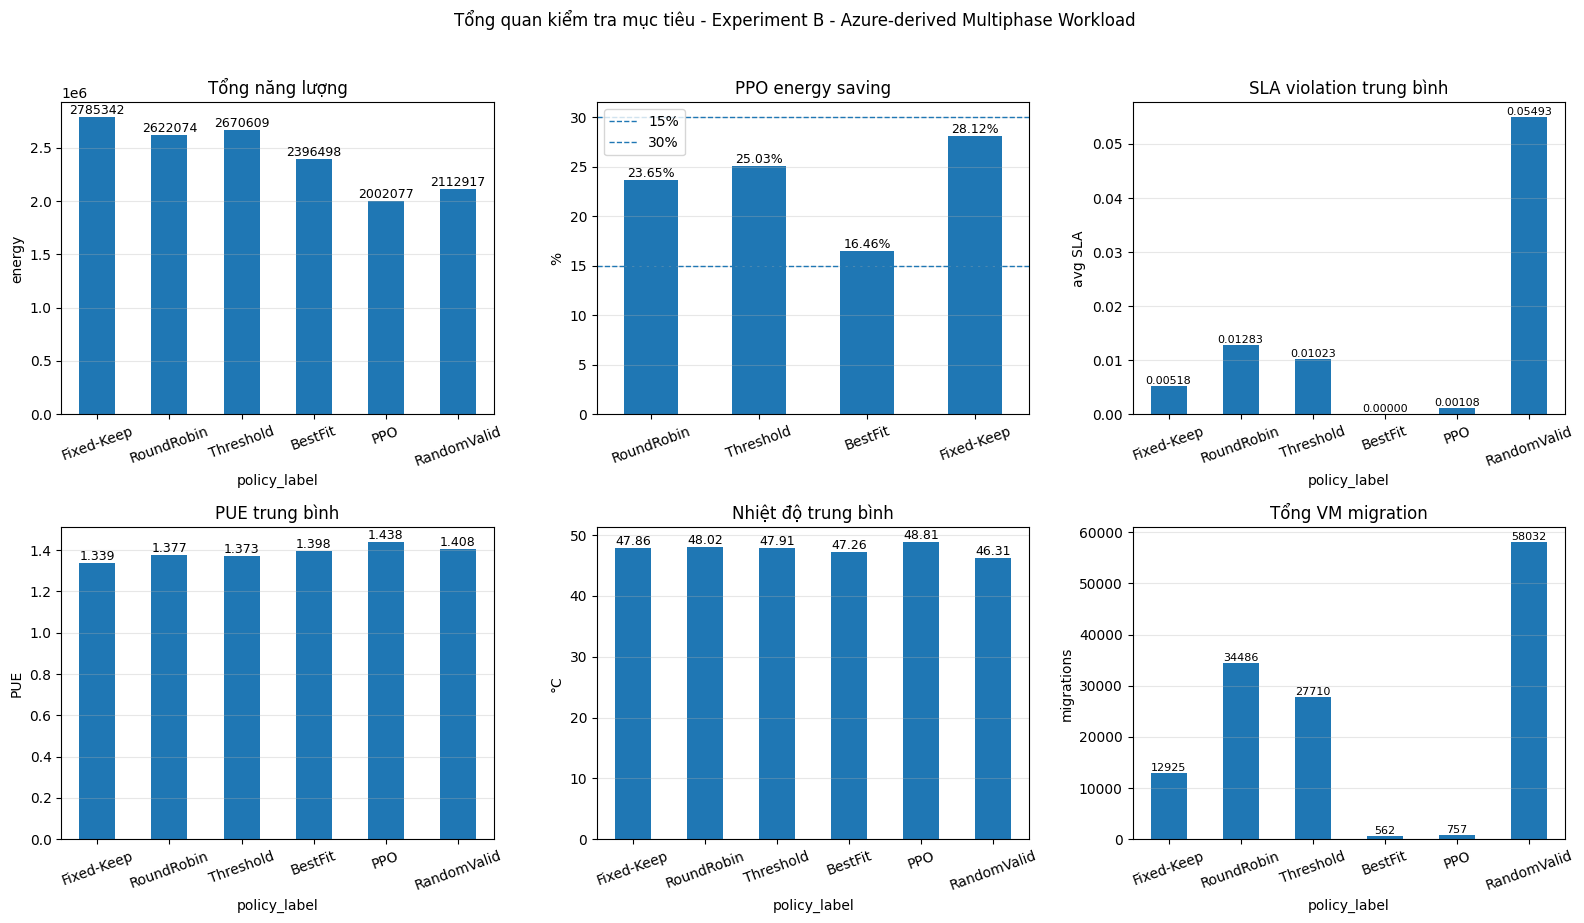

Saved: c:\Users\Minh Chau\Music\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\outputs\v8_1\multiphase_test\v8_1_multiphase_seed42_2500000\figures\02_tong_quan_kiem_tra_muc_tieu.png


In [13]:
plot_df = results_df.copy()
plot_df["policy_label"] = plot_df["policy"].replace({"PPO_v8_1": "PPO"})
energy_order = ["Fixed-Keep", "RoundRobin", "Threshold", "BestFit", "PPO", "RandomValid"]
energy_plot = plot_df.set_index("policy_label").reindex(energy_order)

saving_map = {row["baseline"]: row["energy_saving_pct"] for _, row in energy_saving_df.iterrows()}
saving_plot = pd.Series({
    "RoundRobin": saving_map.get("RoundRobin", np.nan),
    "Threshold": saving_map.get("Threshold", np.nan),
    "BestFit": saving_map.get("BestFit", np.nan),
    "Fixed-Keep": saving_map.get("Fixed-Keep", np.nan),
})

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Tổng năng lượng
energy_plot["total_energy"].plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Tổng năng lượng")
axes[0, 0].set_ylabel("energy")
axes[0, 0].tick_params(axis="x", rotation=20)
axes[0, 0].grid(True, axis="y", alpha=0.3)
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height():.0f}", (p.get_x() + p.get_width()/2, p.get_height()), ha="center", va="bottom", fontsize=9)

# 2. PPO energy saving
saving_plot.plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("PPO energy saving")
axes[0, 1].set_ylabel("%")
axes[0, 1].axhline(15, linestyle="--", linewidth=1, label="15%")
axes[0, 1].axhline(30, linestyle="--", linewidth=1, label="30%")
axes[0, 1].legend()
axes[0, 1].tick_params(axis="x", rotation=20)
axes[0, 1].grid(True, axis="y", alpha=0.3)
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width()/2, p.get_height()), ha="center", va="bottom", fontsize=9)

# 3. SLA
energy_plot["avg_sla"].plot(kind="bar", ax=axes[0, 2])
axes[0, 2].set_title("SLA violation trung bình")
axes[0, 2].set_ylabel("avg SLA")
axes[0, 2].tick_params(axis="x", rotation=20)
axes[0, 2].grid(True, axis="y", alpha=0.3)
for p in axes[0, 2].patches:
    axes[0, 2].annotate(f"{p.get_height():.5f}", (p.get_x() + p.get_width()/2, p.get_height()), ha="center", va="bottom", fontsize=8)

# 4. PUE
energy_plot["avg_pue"].plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("PUE trung bình")
axes[1, 0].set_ylabel("PUE")
axes[1, 0].tick_params(axis="x", rotation=20)
axes[1, 0].grid(True, axis="y", alpha=0.3)
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width()/2, p.get_height()), ha="center", va="bottom", fontsize=9)

# 5. Nhiệt độ
energy_plot["avg_temp"].plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Nhiệt độ trung bình")
axes[1, 1].set_ylabel("°C")
axes[1, 1].tick_params(axis="x", rotation=20)
axes[1, 1].grid(True, axis="y", alpha=0.3)
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width()/2, p.get_height()), ha="center", va="bottom", fontsize=9)

# 6. Migration
energy_plot["total_migrations"].plot(kind="bar", ax=axes[1, 2])
axes[1, 2].set_title("Tổng VM migration")
axes[1, 2].set_ylabel("migrations")
axes[1, 2].tick_params(axis="x", rotation=20)
axes[1, 2].grid(True, axis="y", alpha=0.3)
for p in axes[1, 2].patches:
    axes[1, 2].annotate(f"{p.get_height():.0f}", (p.get_x() + p.get_width()/2, p.get_height()), ha="center", va="bottom", fontsize=8)

fig.suptitle("Tổng quan kiểm tra mục tiêu - Experiment B - Azure-derived Multiphase Workload", y=1.02)
fig.tight_layout()
fig_path = FIG_DIR / "02_tong_quan_kiem_tra_muc_tieu.png"
fig.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

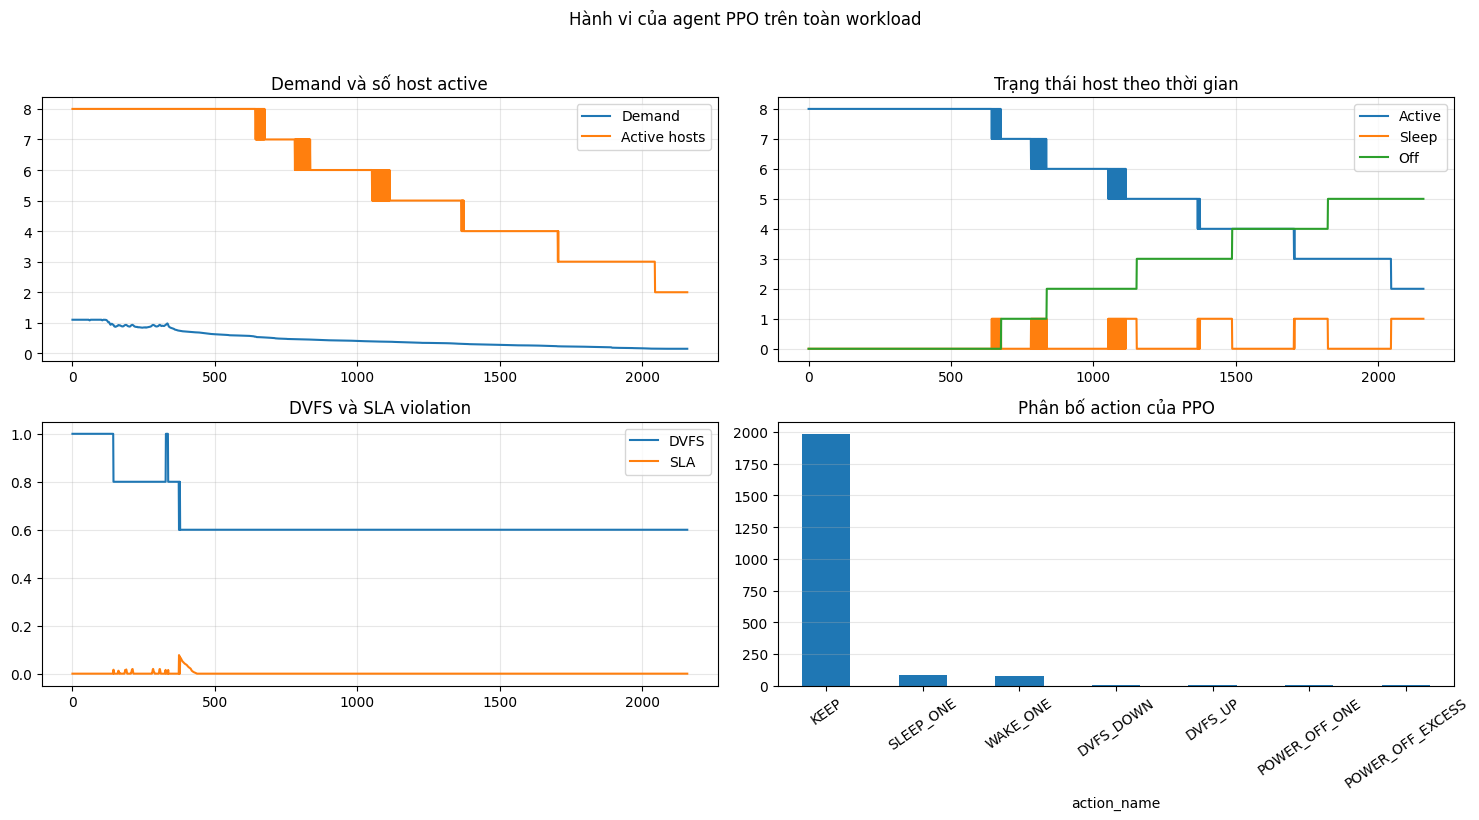

Saved: c:\Users\Minh Chau\Music\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\outputs\v8_1\multiphase_test\v8_1_multiphase_seed42_2500000\figures\03_hanh_vi_agent_ppo.png


In [14]:
# Hình 03: Dashboard hành vi PPO.
df = ppo_full_trace.copy()
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

axes[0, 0].plot(df["step"], df["demand"], label="Demand")
axes[0, 0].plot(df["step"], df["active_hosts"], label="Active hosts")
axes[0, 0].set_title("Demand và số host active")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(df["step"], df["active_hosts"], label="Active")
axes[0, 1].plot(df["step"], df["sleep_hosts"], label="Sleep")
axes[0, 1].plot(df["step"], df["off_hosts"], label="Off")
axes[0, 1].set_title("Trạng thái host theo thời gian")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(df["step"], df["dvfs"], label="DVFS")
axes[1, 0].plot(df["step"], df["sla_violation"], label="SLA")
axes[1, 0].set_title("DVFS và SLA violation")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

action_counts = df["action_name"].value_counts().sort_values(ascending=False)
action_counts.plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Phân bố action của PPO")
axes[1, 1].tick_params(axis="x", rotation=35)
axes[1, 1].grid(True, axis="y", alpha=0.3)

fig.suptitle("Hành vi của agent PPO trên toàn workload", y=1.02)
fig.tight_layout()
fig_path = FIG_DIR / "03_hanh_vi_agent_ppo.png"
fig.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

### 6.1 - Bảng chẩn đoán nhanh

Cell này giữ lại để nhìn nhanh `KEEP rate`, `distinct actions`, `POWER_OFF_ONE`, và phase behavior. Nó không tạo thêm quá nhiều hình.

Trace PPO_v8_1: 2159 timesteps
Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
demand,2159.0,NaN,NaN,NaN,0.462841,0.269365,0.15,0.257854,0.384946,0.603595,1.1
phase,2159,3,low,1140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
action_name,2159,7,KEEP,1981,NaN,NaN,NaN,NaN,NaN,NaN,NaN
active_hosts,2159.0,NaN,NaN,NaN,5.552571,2.026674,2.0,4.0,6.0,8.0,8.0
sleep_hosts,2159.0,NaN,NaN,NaN,0.214451,0.410536,0.0,0.0,0.0,0.0,1.0
off_hosts,2159.0,NaN,NaN,NaN,2.232978,1.858005,0.0,0.0,2.0,4.0,5.0
dvfs,2159.0,NaN,NaN,NaN,0.648912,0.114141,0.6,0.6,0.6,0.6,1.0
power_total,2159.0,NaN,NaN,NaN,927.316959,499.635212,323.163971,569.222324,828.096941,1173.944772,2252.227528
pue,2159.0,NaN,NaN,NaN,1.438327,0.024872,1.327496,1.420115,1.434041,1.452595,1.510513
avg_temp,2159.0,NaN,NaN,NaN,48.814064,10.198579,33.928341,40.286345,46.963745,59.361147,65.174423


Action distribution:


,action_name,count,pct
0,KEEP,1981,91.755442
1,SLEEP_ONE,85,3.937008
2,WAKE_ONE,80,3.705419
3,DVFS_DOWN,5,0.231589
4,DVFS_UP,3,0.138953
5,POWER_OFF_ONE,3,0.138953
6,POWER_OFF_EXCESS,2,0.092635


KEEP rate = 91.76%
Distinct actions = 7
POWER_OFF_ONE count = 3
[NOTE] KEEP hơi cao, cần xem phase behavior trước khi kết luận.
Phase diagnostic:


,phase,steps,demand_mean,active_mean,sleep_mean,off_mean,dvfs_mean,sla_mean,pue_mean,temp_mean,migrations_sum
1,low,1140,0.263033,3.865789,0.366667,3.767544,0.600000,0.000000,1.442759,40.465906,243
2,medium,649,0.531602,7.120185,0.069337,0.810478,0.601849,0.002874,1.425189,55.055703,326
0,high,370,0.957857,8.000000,0.000000,0.000000,0.882162,0.001269,1.447717,63.587245,188


Saved: c:\Users\Minh Chau\Music\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\outputs\v8_1\multiphase_test\v8_1_multiphase_seed42_2500000\figures\ppo_phase_diagnostic_v2style.csv


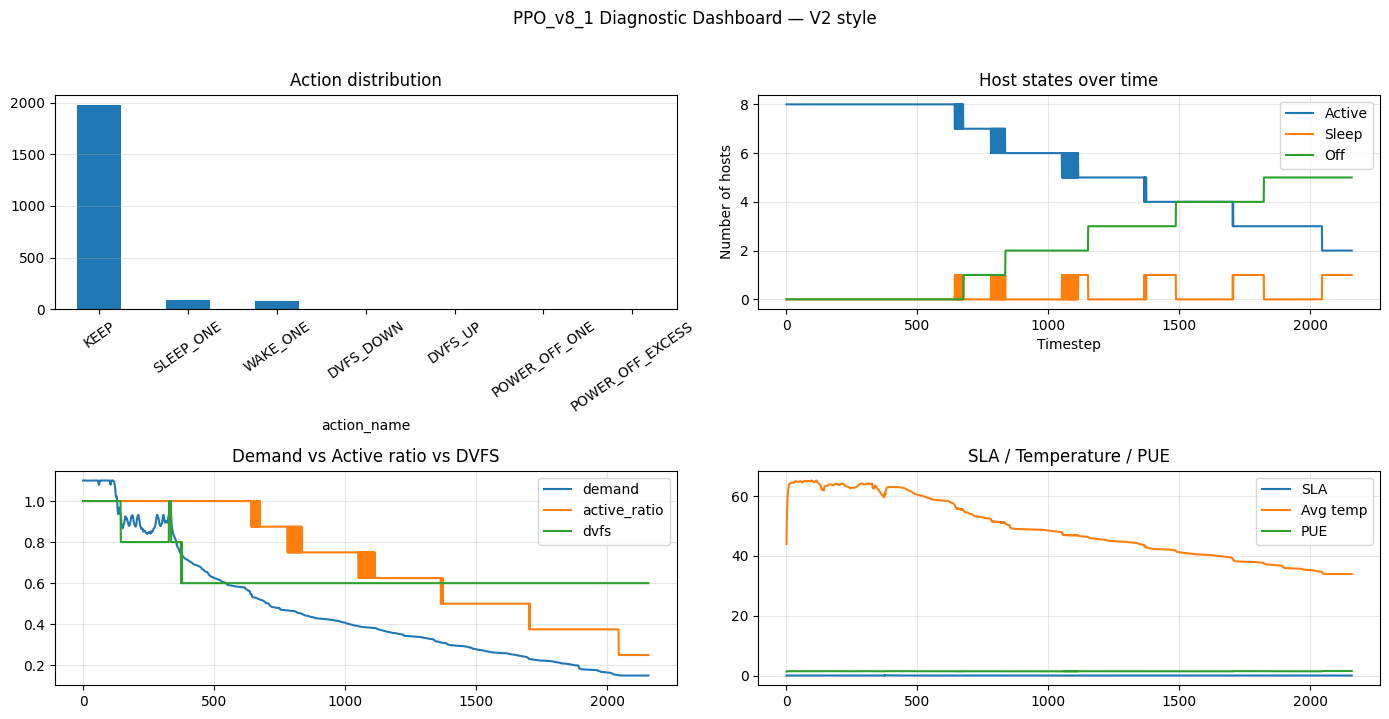

Saved: c:\Users\Minh Chau\Music\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\outputs\v8_1\multiphase_test\v8_1_multiphase_seed42_2500000\figures\03a_ppo_diagnostic_v2style.png


In [15]:
def diagnose_ppo_behavior_v2style(trace: pd.DataFrame, out_dir: Path, policy_name: str = "PPO_v8_1"):
    trace = trace.copy()
    print(f"Trace {policy_name}: {len(trace)} timesteps")

    core_cols = [
        "demand", "phase", "action_name",
        "active_hosts", "sleep_hosts", "off_hosts", "dvfs",
        "power_total", "pue", "avg_temp", "max_temp",
        "sla_violation", "migrations",
    ]
    core_cols = [c for c in core_cols if c in trace.columns]

    print("Summary statistics:")
    display(trace[core_cols].describe(include="all").T)

    if "action_name" in trace.columns:
        action_counts = (
            trace["action_name"]
            .value_counts()
            .rename_axis("action_name")
            .reset_index(name="count")
        )
        action_counts["pct"] = action_counts["count"] / len(trace) * 100
        print("Action distribution:")
        display(action_counts)

        keep_pct = float(action_counts.loc[action_counts["action_name"] == "KEEP", "pct"].iloc[0]) if (action_counts["action_name"] == "KEEP").any() else 0.0
        distinct_actions = int(action_counts.shape[0])
        power_off_count = int((trace["action_name"] == "POWER_OFF_ONE").sum())
        print(f"KEEP rate = {keep_pct:.2f}%")
        print(f"Distinct actions = {distinct_actions}")
        print(f"POWER_OFF_ONE count = {power_off_count}")

        if keep_pct > 95:
            print("[WARN] KEEP quá cao: agent có dấu hiệu bảo thủ.")
        elif keep_pct > 90:
            print("[NOTE] KEEP hơi cao, cần xem phase behavior trước khi kết luận.")
        else:
            print("[OK] KEEP không quá cao.")

    if {"phase", "active_hosts", "sleep_hosts", "off_hosts", "dvfs", "sla_violation", "avg_temp", "pue"}.issubset(trace.columns):
        phase_diag = (
            trace.groupby("phase")
            .agg(
                steps=("phase", "size"),
                demand_mean=("demand", "mean"),
                active_mean=("active_hosts", "mean"),
                sleep_mean=("sleep_hosts", "mean"),
                off_mean=("off_hosts", "mean"),
                dvfs_mean=("dvfs", "mean"),
                sla_mean=("sla_violation", "mean"),
                pue_mean=("pue", "mean"),
                temp_mean=("avg_temp", "mean"),
                migrations_sum=("migrations", "sum"),
            )
            .reset_index()
        )
        phase_order = ["low", "medium", "high"]
        phase_diag["phase"] = pd.Categorical(phase_diag["phase"], categories=phase_order, ordered=True)
        phase_diag = phase_diag.sort_values("phase")
        print("Phase diagnostic:")
        display(phase_diag)

        out_csv = out_dir / "ppo_phase_diagnostic_v2style.csv"
        phase_diag.to_csv(out_csv, index=False)
        print("Saved:", out_csv)

    fig, axes = plt.subplots(2, 2, figsize=(14, 7))

    if "action_name" in trace.columns:
        trace["action_name"].value_counts().plot(kind="bar", ax=axes[0, 0])
        axes[0, 0].set_title("Action distribution")
        axes[0, 0].tick_params(axis="x", rotation=35)
        axes[0, 0].grid(True, axis="y", alpha=0.3)

    x = trace["step"] if "step" in trace.columns else np.arange(len(trace))
    for col, label in [("active_hosts", "Active"), ("sleep_hosts", "Sleep"), ("off_hosts", "Off")]:
        if col in trace.columns:
            axes[0, 1].plot(x, trace[col], label=label)
    axes[0, 1].set_title("Host states over time")
    axes[0, 1].set_xlabel("Timestep")
    axes[0, 1].set_ylabel("Number of hosts")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    if "demand" in trace.columns:
        axes[1, 0].plot(x, trace["demand"], label="demand")
    if "active_hosts" in trace.columns:
        axes[1, 0].plot(x, trace["active_hosts"] / max(1, base_train_config.max_hosts), label="active_ratio")
    if "dvfs" in trace.columns:
        axes[1, 0].plot(x, trace["dvfs"], label="dvfs")
    axes[1, 0].set_title("Demand vs Active ratio vs DVFS")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    for col, label in [("sla_violation", "SLA"), ("avg_temp", "Avg temp"), ("pue", "PUE")]:
        if col in trace.columns:
            axes[1, 1].plot(x, trace[col], label=label)
    axes[1, 1].set_title("SLA / Temperature / PUE")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    fig.suptitle(f"{policy_name} Diagnostic Dashboard — V2 style", y=1.02)
    fig.tight_layout()

    fig_path = out_dir / "03a_ppo_diagnostic_v2style.png"
    fig.savefig(fig_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

diagnose_ppo_behavior_v2style(ppo_full_trace, FIG_DIR, "PPO_v8_1")


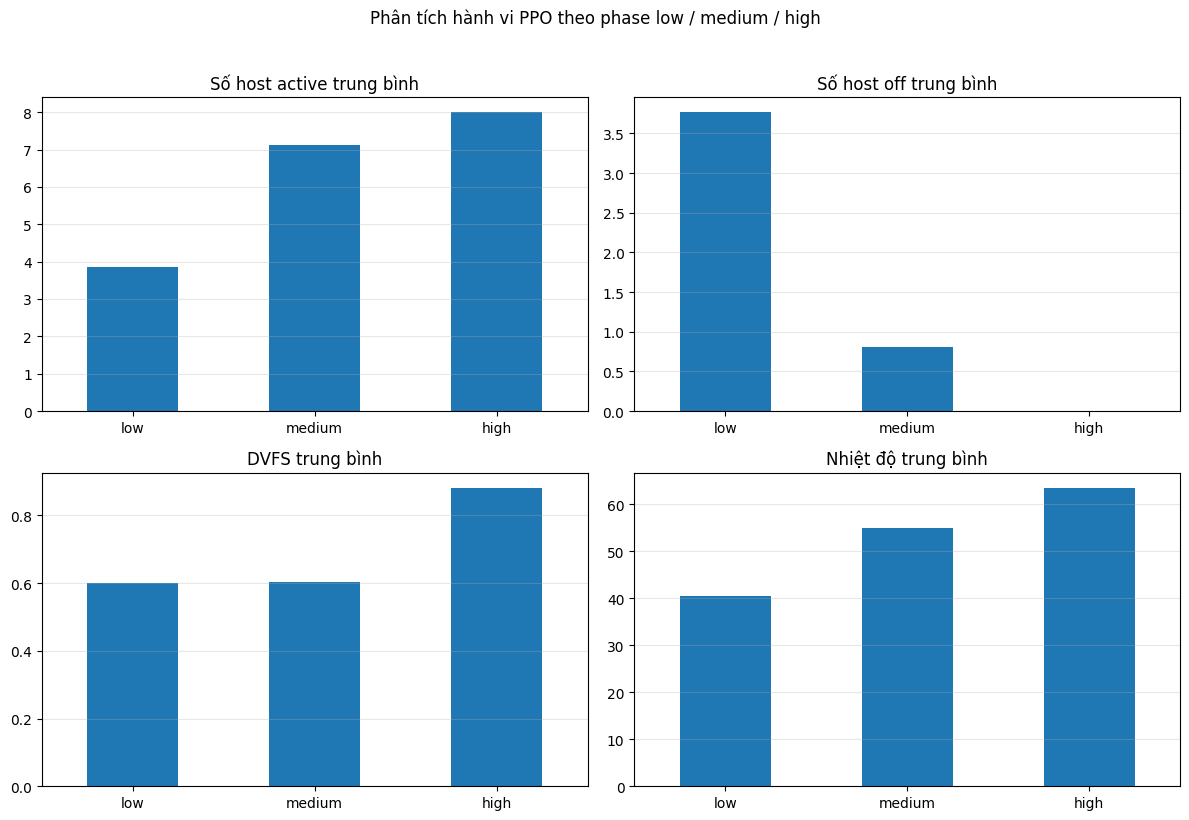

Saved: c:\Users\Minh Chau\Music\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\outputs\v8_1\multiphase_test\v8_1_multiphase_seed42_2500000\figures\04_phan_tich_theo_phase_ppo.png


In [16]:
phase_plot = ppo_phase_summary.dropna().copy()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
phase_metrics = [
    ("active_mean", "Số host active trung bình"),
    ("off_mean", "Số host off trung bình"),
    ("dvfs_mean", "DVFS trung bình"),
    ("temp_mean", "Nhiệt độ trung bình"),
]
for ax, (col, title) in zip(axes.ravel(), phase_metrics):
    phase_plot[col].plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.grid(True, axis="y", alpha=0.3)
fig.suptitle("Phân tích hành vi PPO theo phase low / medium / high", y=1.02)
fig.tight_layout()
fig_path = FIG_DIR / "04_phan_tich_theo_phase_ppo.png"
fig.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

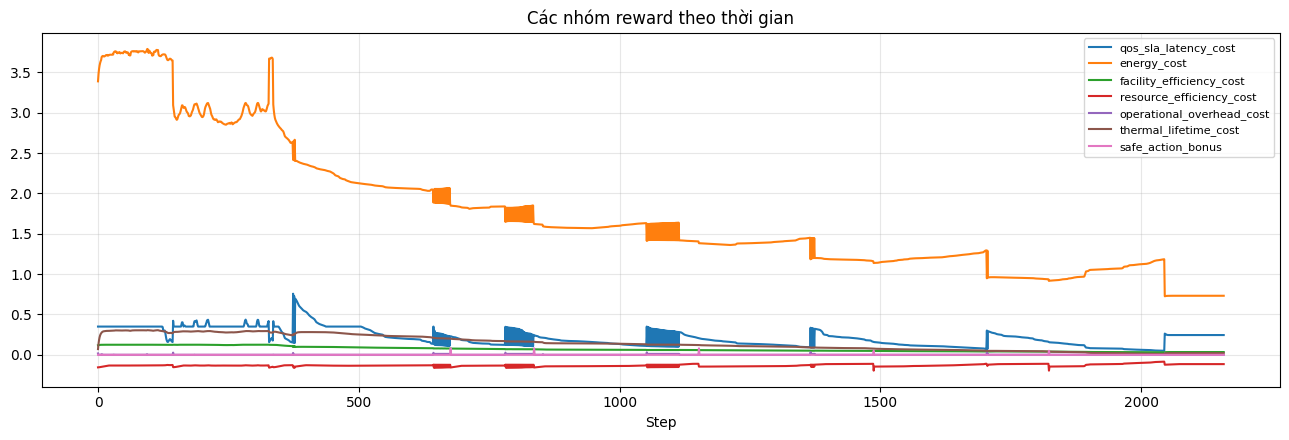

Saved: c:\Users\Minh Chau\Music\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\NT549_Q21_DRL_ERM_Cloud_formula_reward_fixed_FLAT\outputs\v8_1\multiphase_test\v8_1_multiphase_seed42_2500000\figures\05_nhom_reward_theo_thoi_gian.png


In [17]:
reward_group_cols = [c for c in ppo_full_trace.columns if c.startswith("reward_group_")]
if reward_group_cols:
    fig, ax = plt.subplots(figsize=(13, 4.5))
    for col in reward_group_cols:
        ax.plot(ppo_full_trace["step"], ppo_full_trace[col], label=col.replace("reward_group_", ""))
    ax.set_title("Các nhóm reward theo thời gian")
    ax.set_xlabel("Step")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    fig_path = FIG_DIR / "05_nhom_reward_theo_thoi_gian.png"
    fig.savefig(fig_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)
else:
    print("Không có reward_group_* trong trace.")

## 7. Goal check ngắn gọn

In [18]:
ppo_row = results_df[results_df["policy"] == "PPO_v8_1"].iloc[0]

def get_saving(baseline: str) -> float:
    row = energy_saving_df[energy_saving_df["baseline"] == baseline]
    return float(row["energy_saving_pct"].iloc[0]) if len(row) else float("nan")

phase_ok = set(ppo_phase_summary.dropna().index) >= {"low", "medium", "high"}
low_off = float(ppo_phase_summary.loc["low", "off_mean"]) if "low" in ppo_phase_summary.index and not pd.isna(ppo_phase_summary.loc["low", "off_mean"]) else 0.0
high_off = float(ppo_phase_summary.loc["high", "off_mean"]) if "high" in ppo_phase_summary.index and not pd.isna(ppo_phase_summary.loc["high", "off_mean"]) else 999.0

bestfit_mig = float(results_df.loc[results_df["policy"] == "BestFit", "total_migrations"].iloc[0]) if "BestFit" in set(results_df["policy"]) else np.nan
ppo_mig = float(ppo_row["total_migrations"])

checks = [
    ("Full eval covers low/medium/high", phase_ok, "ppo_phase_summary must have all 3 phases"),
    ("Energy saving vs RoundRobin >= 15%", get_saving("RoundRobin") >= 15.0, f"actual={get_saving('RoundRobin'):.2f}%"),
    ("Energy saving vs Threshold >= 15%", get_saving("Threshold") >= 15.0, f"actual={get_saving('Threshold'):.2f}%"),
    ("Energy saving vs BestFit >= 12%", get_saving("BestFit") >= 12.0, f"actual={get_saving('BestFit'):.2f}%"),
    ("Average SLA <= 1%", float(ppo_row["avg_sla"]) <= 0.01, f"actual={float(ppo_row['avg_sla']):.4f}"),
    ("SLA step rate <= 10%", float(ppo_row["sla_step_rate"]) <= 0.10, f"actual={float(ppo_row['sla_step_rate']):.2%}"),
    ("KEEP rate < 90%", float(ppo_row["keep_rate"]) < 0.95, f"actual={float(ppo_row['keep_rate']):.2%}"),
    ("At least 3 distinct actions", int(ppo_row["distinct_actions"]) >= 3, f"actual={int(ppo_row['distinct_actions'])}"),
    ("Low phase off_hosts_mean >= 1", low_off >= 1.0, f"actual={low_off:.2f}"),
    ("High phase off_hosts_mean <= 0.5", high_off <= 0.5, f"actual={high_off:.2f}"),
    ("Avg temp <= 50C", float(ppo_row["avg_temp"]) <= 50.0, f"actual={float(ppo_row['avg_temp']):.2f}"),
    ("High phase temp <= 62C", float(ppo_phase_summary.loc["high", "temp_mean"]) <= 62.0 if "high" in ppo_phase_summary.index else False, f"actual={float(ppo_phase_summary.loc['high', 'temp_mean']):.2f}" if "high" in ppo_phase_summary.index else "missing high"),
    ("Migration <= 3x BestFit", ppo_mig <= 3.0 * max(bestfit_mig, 1.0), f"ppo={ppo_mig:.0f}, bestfit={bestfit_mig:.0f}"),
]

goal_df = pd.DataFrame(checks, columns=["goal", "passed", "detail"])
goal_df.to_csv(RUN_DIR / "goal_check_v8_1.csv", index=False)
display(goal_df)

passed = int(goal_df["passed"].sum())
total = len(goal_df)
print(f"Goal check: {passed}/{total} passed")
if passed < total:
    print("Chưa đạt hết mục tiêu. Xem các dòng failed để quyết định dùng làm main/ablation.")
else:
    print("Đạt toàn bộ goal check tối thiểu.")

,goal,passed,detail
0,Full eval covers low/medium/high,True,ppo_phase_summary must have all 3 phases
1,Energy saving vs RoundRobin >= 15%,True,actual=23.65%
2,Energy saving vs Threshold >= 15%,True,actual=25.03%
3,Energy saving vs BestFit >= 12%,True,actual=16.46%
4,Average SLA <= 1%,True,actual=0.0011
5,SLA step rate <= 10%,True,actual=4.91%
6,KEEP rate < 90%,True,actual=91.76%
7,At least 3 distinct actions,True,actual=7
8,Low phase off_hosts_mean >= 1,True,actual=3.77
9,High phase off_hosts_mean <= 0.5,True,actual=0.00


Goal check: 12/13 passed
Chưa đạt hết mục tiêu. Xem các dòng failed để quyết định dùng làm main/ablation.
